PLAN DU SCRIPT

──────────────

0. Imports et configuration
1. Chargement et extraction de la population cible
2. Inspection générale du dataset
3. Analyse univariée
   3a. Variables numériques (Age, Revenu)
   3b. Variables catégorielles et binaires
4. Analyse bivariée — croisements orientés SUJET
   4a. Revenu × profil socio-économique
   4b. Comportements financiers × profil
   4c. Éligibilité documentaire × profil
   4d. Comportements financiers × géographie
5. Tests statistiques
   5a. Normalité (Shapiro-Wilk, histogramme, QQ-plot)
   5b. Comparaison de groupes — ANOVA / Mann-Whitney
   5c. Associations — Khi-deux + V de Cramér
6. Synthèse des indicateurs clés (tableau récapitulatif)
"""

In [13]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 0. IMPORTS ET CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import openpyxl
from scipy import stats
from scipy.stats import (shapiro, mannwhitneyu, kruskal,
                         chi2_contingency, spearmanr)

# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120,
})

# Dossier de sortie des graphiques (créer manuellement si besoin)
# import os; os.makedirs("outputs/figures", exist_ok=True)
# Pour sauvegarder : plt.savefig("outputs/figures/nom.png", bbox_inches="tight")

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. CHARGEMENT ET EXTRACTION DE LA POPULATION CIBLE
# ══════════════════════════════════════════════════════════════════════════════

# Chargement de la feuille nettoyée
df_brut = pd.read_excel(
    r"C:\Users\DELL\Desktop\Formation Data-science_FRST_FDS\Projet_Capstone\Segmentation_Inclusion_Financiere_Groupe5\Donnees\Donnees_Nettoyees\FinScope_Haiti_2018_Données nettoyées.xlsx",
    sheet_name="Données_Nettoyées"
)
print(f"Dataset complet chargé : {df_brut.shape[0]} individus × {df_brut.shape[1]} variables\n")

# ── Extraction de la population cible ────────────────────────────────────────
# On conserve uniquement les individus n'ayant JAMAIS eu accès au crédit formel.
# C'est la population centrale de notre segmentation.
df = df_brut[df_brut["Jamais_Eu_Credit_Formel"] == "Oui"].copy()
df.reset_index(drop=True, inplace=True)

print(f"Population cible (exclus crédit formel) : {len(df)} individus")
print(f"Soit {len(df)/len(df_brut)*100:.1f}% du dataset complet\n")

# ── Variables de référence ────────────────────────────────────────────────────
VARS_NUM  = ["Age", "Revenu_Mensuel_HTG"]

VARS_BIN  = [
    "CIN_Carte_Identite", "Membre_Tontine_Sol", "Mobile_Money",
    "Credit_Informel", "Manque_Argent_Frequent", "Epargne_Formelle",
    "Possede_Telephone", "Possede_Smartphone", "Actes_Naissance",
    "NIF_Matricule_Fiscal", "Titre_Propriete", "Implique_Agriculture",
    "Compte_Bancaire", "Acces_Internet",
]
# On vérifie quelles binaires existent réellement dans le dataset
VARS_BIN = [v for v in VARS_BIN if v in df.columns]

VARS_CAT  = [
    "Departement", "Milieu", "Genre", "Tranche_Age", "Niveau_Education",
    "Secteur_Activite", "Niveau_Inclusion_Financiere", "Statut_Logement",
    "Source_Energie", "Planification_Financiere", "Controle_Depenses",
    "Raison_Principale_Manque_Argent", "Besoin_Education_Financiere",
]
VARS_CAT = [v for v in VARS_CAT if v in df.columns]

Dataset complet chargé : 4269 individus × 34 variables

Population cible (exclus crédit formel) : 4016 individus
Soit 94.1% du dataset complet



In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. INSPECTION GÉNÉRALE
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("2. INSPECTION GÉNÉRALE")
print("=" * 65)

# ── 2a. Aperçu des premières lignes ──────────────────────────────────────────
print("\n--- 2a. Aperçu (5 premières lignes) ---")
print(df.head())

# ── 2b. Types et valeurs manquantes ──────────────────────────────────────────
print("\n--- 2b. Types, valeurs manquantes, valeurs uniques ---")
resume = pd.DataFrame({
    "Type"              : df.dtypes,
    "Non_nuls"          : df.notna().sum(),
    "Manquants"         : df.isna().sum(),
    "Pct_manquant (%)"  : (df.isna().sum() / len(df) * 100).round(2),
    "Valeurs_uniques"   : df.nunique(),
})
print(resume)

# ── 2c. Doublons ─────────────────────────────────────────────────────────────
print(f"\n--- 2c. Doublons sur ID_Individu ---")
n_doublons = df.duplicated(subset=["ID_Individu"]).sum()
print(f"Nombre de doublons : {n_doublons}")

# ── 2d. Statistiques descriptives globales ────────────────────────────────────
print("\n--- 2d. Statistiques descriptives — variables numériques ---")
print(df[VARS_NUM].describe().round(2))

2. INSPECTION GÉNÉRALE

--- 2a. Aperçu (5 premières lignes) ---
    ID_Individu          Departement  Milieu  Genre Tranche_Age  Age  \
0  HTI2018_0001           Grand-Anse   Rural  Homme       35-44   36   
1  HTI2018_0002  Aire Métropolitaine  Urbain  Femme       25-34   29   
2  HTI2018_0003             Nord-Est  Urbain  Homme       45-60   55   
3  HTI2018_0004  Aire Métropolitaine   Rural  Femme       25-34   26   
4  HTI2018_0005           Artibonite  Urbain  Femme       18-24   23   

  Niveau_Education      Secteur_Activite  Revenu_Mensuel_HTG  \
0       Secondaire  Artisanat/Production                3514   
1         Primaire  Artisanat/Production                7021   
2    Non scolarisé     Commerce informel                4151   
3         Primaire   Agriculture/Élevage                2541   
4       Secondaire    Services/Transport                4453   

  Possede_Telephone  ... Epargne_Formelle Membre_Tontine_Sol Mobile_Money  \
0               Non  ...              Non


3. ANALYSE UNIVARIÉE

--- 3a. Variables numériques : Age et Revenu ---

  Age
    Moyenne : 36.66  |  Médiane : 34.00  |  Écart-type : 16.02
    Min : 15  |  Max : 79
    Asymétrie (skewness) : 0.734  |  Aplatissement (kurtosis) : -0.192

  Revenu_Mensuel_HTG
    Moyenne : 3589.48  |  Médiane : 2756.00  |  Écart-type : 3445.42
    Min : 0  |  Max : 29110
    Asymétrie (skewness) : 2.117  |  Aplatissement (kurtosis) : 6.230


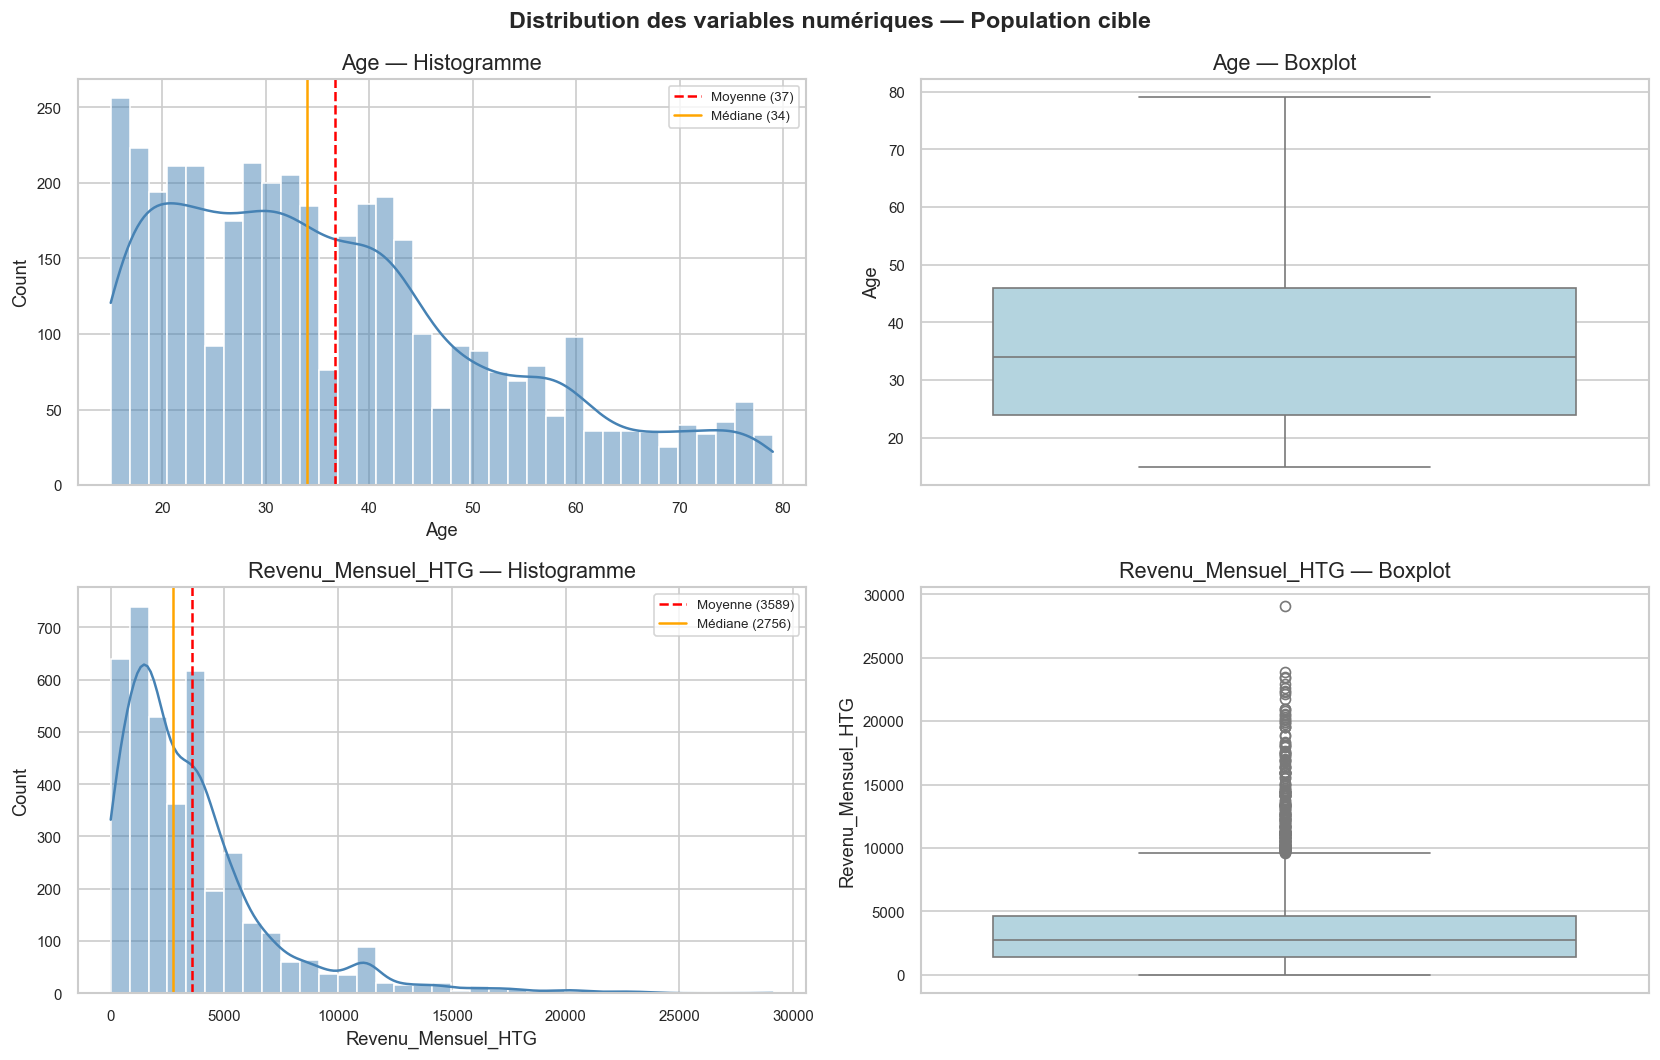


--- 3b. Fréquences — variables catégorielles et binaires ---

  Departement (10 modalités)
    Aire Métropolitaine                      :  1461  (36.4%)
    Artibonite                               :   503  (12.5%)
    Nord                                     :   393  (9.8%)
    Sud                                      :   367  (9.1%)
    Ouest (reste)                            :   314  (7.8%)
    Centre                                   :   281  (7.0%)
    Grand-Anse                               :   201  (5.0%)
    Nord-Est                                 :   181  (4.5%)
    Nippes                                   :   179  (4.5%)
    Nord-Ouest                               :   136  (3.4%)

  Milieu (2 modalités)
    Urbain                                   :  2840  (70.7%)
    Rural                                    :  1176  (29.3%)

  Genre (2 modalités)
    Femme                                    :  2047  (51.0%)
    Homme                                    :  1969  (49.0%)



C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\3857555546.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette="Blues_r", orient="h")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\3857555546.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette="Blues_r", orient="h")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\3857555546.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette="Blues_r", orient="h")
C:\User

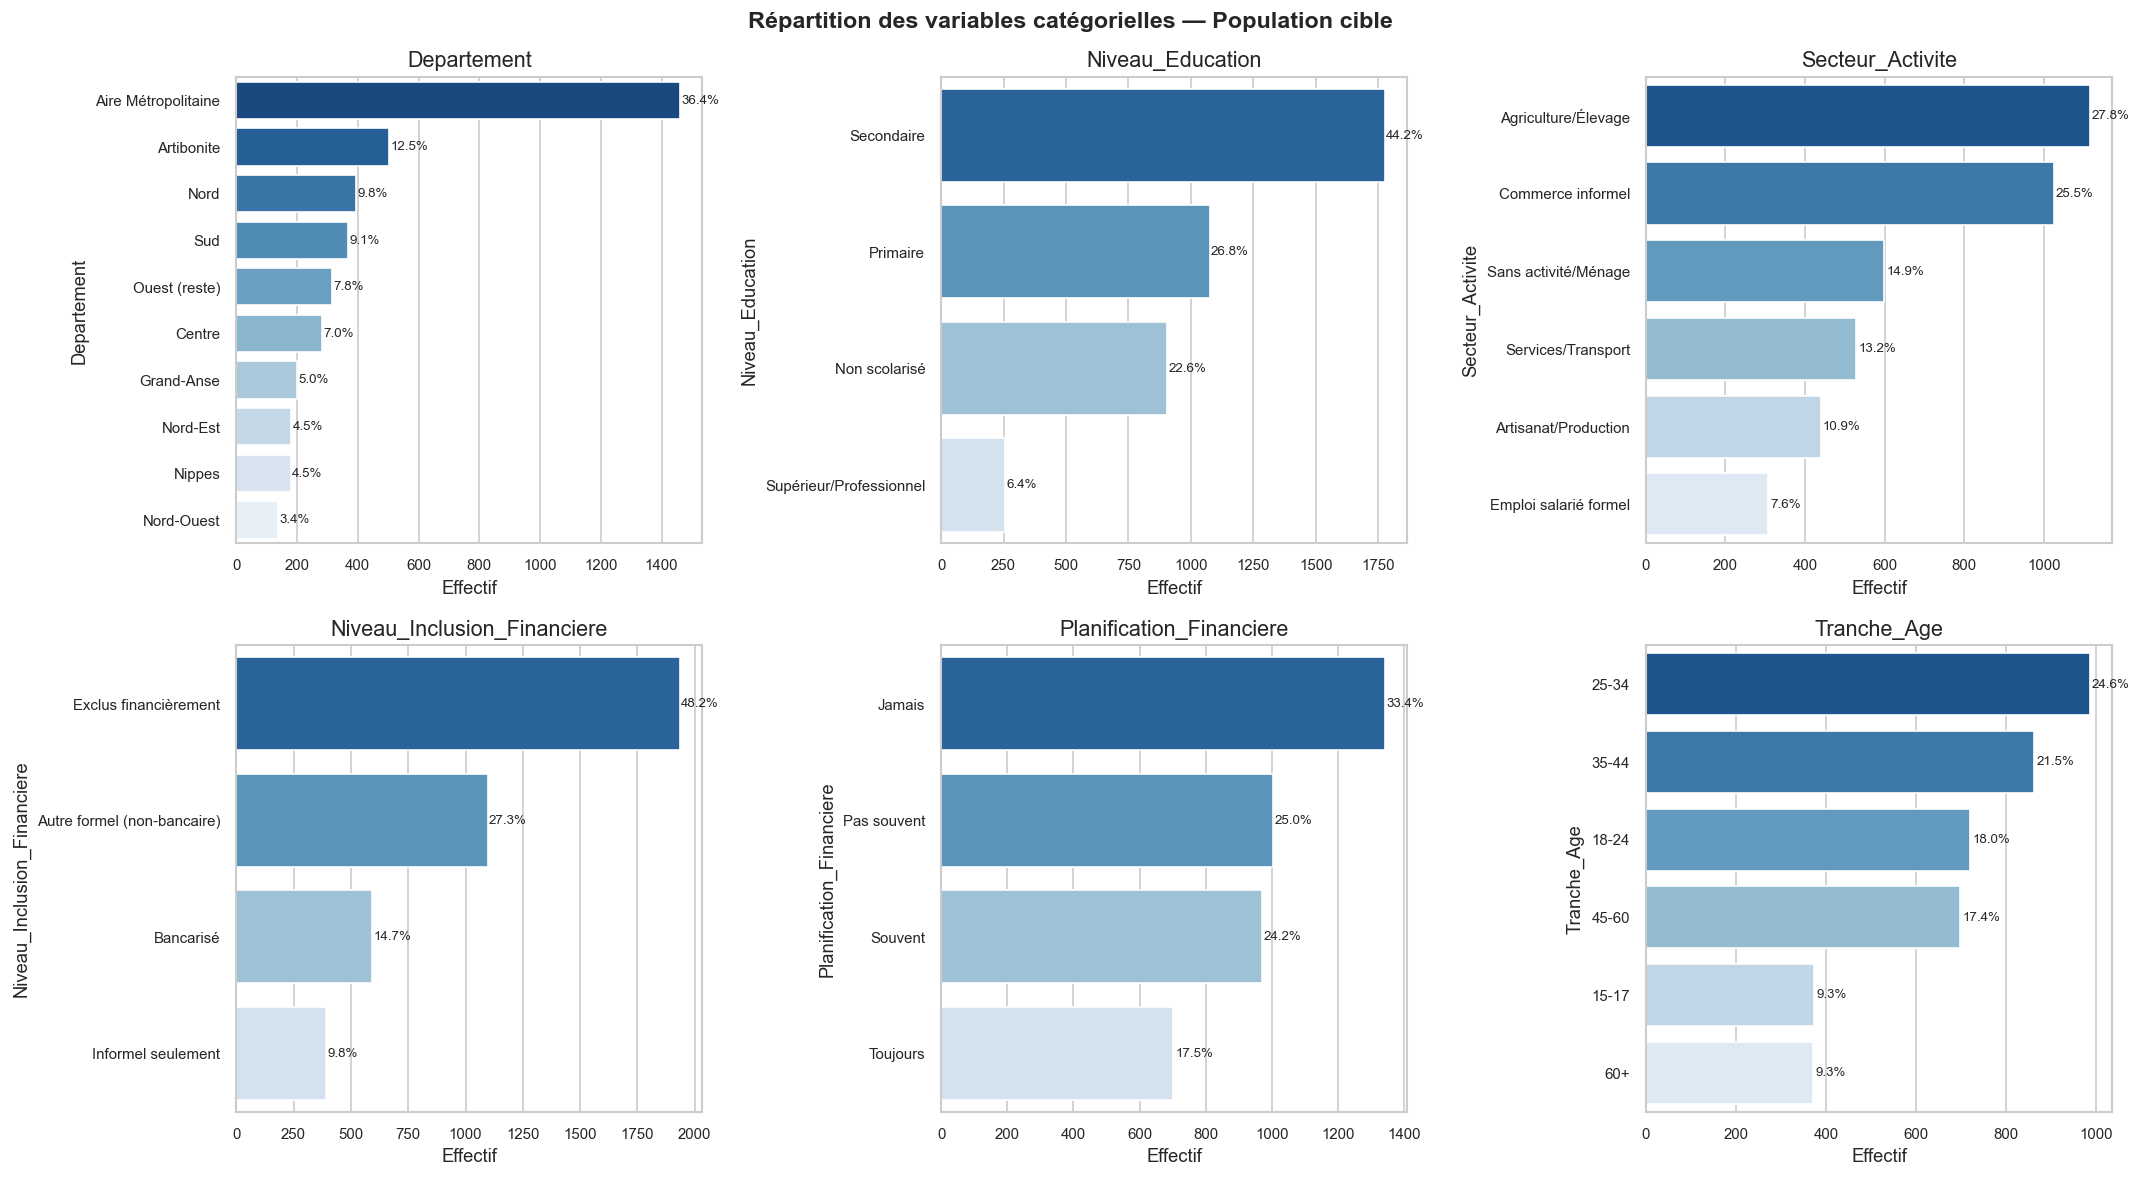


--- Taux de 'Oui' pour les variables binaires ---
Series([], )


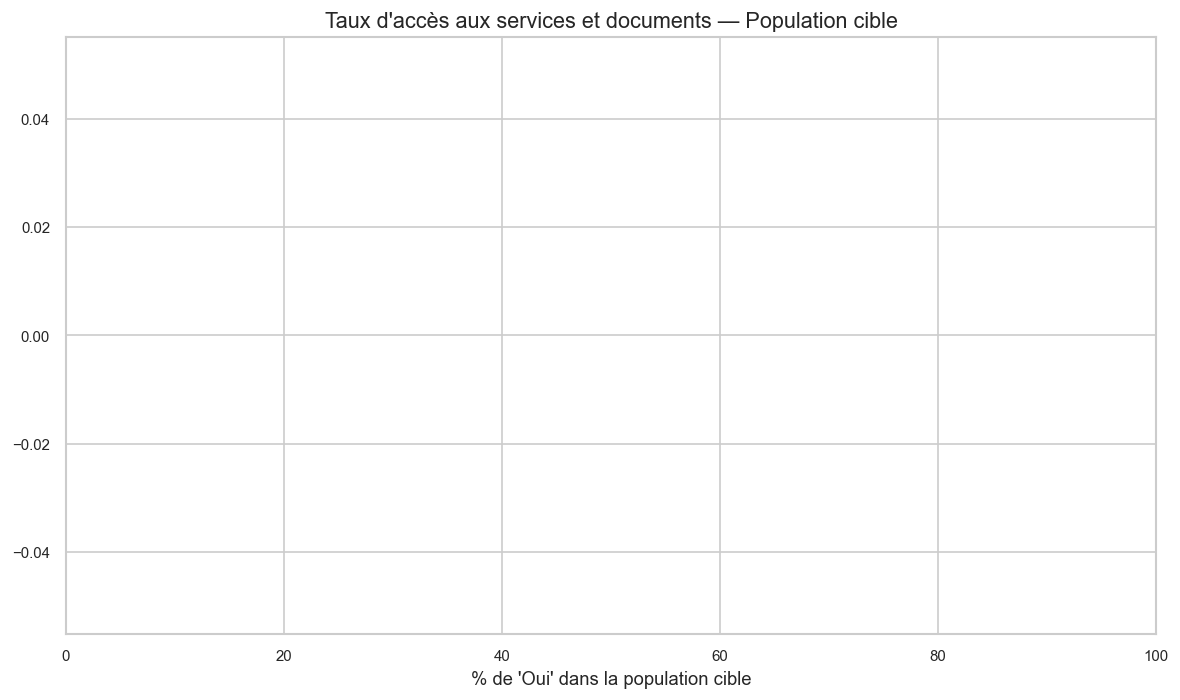

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. ANALYSE UNIVARIÉE
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("3. ANALYSE UNIVARIÉE")
print("=" * 65)

# ── 3a. Variables numériques ──────────────────────────────────────────────────
print("\n--- 3a. Variables numériques : Age et Revenu ---")

for var in VARS_NUM:
    s = df[var].describe()
    skew  = df[var].skew()
    kurt  = df[var].kurtosis()
    print(f"\n  {var}")
    print(f"    Moyenne : {s['mean']:.2f}  |  Médiane : {s['50%']:.2f}  |  Écart-type : {s['std']:.2f}")
    print(f"    Min : {s['min']:.0f}  |  Max : {s['max']:.0f}")
    print(f"    Asymétrie (skewness) : {skew:.3f}  |  Aplatissement (kurtosis) : {kurt:.3f}")

# Graphique 1 — Distribution Age et Revenu (histogramme + KDE + boxplot)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Distribution des variables numériques — Population cible", fontsize=14, fontweight="bold")

for i, var in enumerate(VARS_NUM):
    # Histogramme + KDE
    sns.histplot(df[var], bins=35, kde=True, ax=axes[i][0], color="steelblue")
    axes[i][0].axvline(df[var].mean(),   color="red",    linestyle="--", label=f"Moyenne ({df[var].mean():.0f})")
    axes[i][0].axvline(df[var].median(), color="orange", linestyle="-",  label=f"Médiane ({df[var].median():.0f})")
    axes[i][0].set_title(f"{var} — Histogramme")
    axes[i][0].legend(fontsize=8)
    # Boxplot
    sns.boxplot(y=df[var], ax=axes[i][1], color="lightblue")
    axes[i][1].set_title(f"{var} — Boxplot")

plt.tight_layout()
plt.show()

# ── 3b. Variables catégorielles et binaires ───────────────────────────────────
print("\n--- 3b. Fréquences — variables catégorielles et binaires ---")

# Tableau de fréquences texte
for var in VARS_CAT + VARS_BIN:
    vc = df[var].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(1)
    print(f"\n  {var} ({df[var].nunique()} modalités)")
    for mod, cnt in vc.items():
        print(f"    {str(mod):<40} : {cnt:>5}  ({pct[mod]:.1f}%)")

# Graphique 2 — Variables catégorielles principales (6 variables)
vars_plot_cat = [
    "Departement", "Niveau_Education", "Secteur_Activite",
    "Niveau_Inclusion_Financiere", "Planification_Financiere", "Tranche_Age"
]
vars_plot_cat = [v for v in vars_plot_cat if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Répartition des variables catégorielles — Population cible", fontsize=14, fontweight="bold")
axes = axes.flatten()
for i, var in enumerate(vars_plot_cat):
    vc = df[var].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette="Blues_r", orient="h")
    axes[i].set_title(var)
    axes[i].set_xlabel("Effectif")
    # Ajouter les pourcentages
    for j, v in enumerate(vc.values):
        axes[i].text(v + 5, j, f"{v/len(df)*100:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

# Graphique 3 — Variables binaires (taux de "Oui")
print("\n--- Taux de 'Oui' pour les variables binaires ---")
taux_oui = {}
for var in VARS_BIN:
    if df[var].dtype == object:
        taux_oui[var] = (df[var] == "Oui").mean() * 100
taux_oui = pd.Series(taux_oui).sort_values(ascending=True)
print(taux_oui.round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(taux_oui.index, taux_oui.values, color="steelblue")
ax.set_xlabel("% de 'Oui' dans la population cible")
ax.set_title("Taux d'accès aux services et documents — Population cible")
for bar, val in zip(bars, taux_oui.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


4. ANALYSE BIVARIÉE

--- 4a. Revenu mensuel × profil socio-économique ---

  Revenu médian par groupe :

  Secteur_Activite
    Emploi salarié formel                    :   11,207 HTG
    Services/Transport                       :    5,215 HTG
    Commerce informel                        :    4,151 HTG
    Artisanat/Production                     :    3,380 HTG
    Agriculture/Élevage                      :    1,592 HTG
    Sans activité/Ménage                     :      631 HTG

  Milieu
    Urbain                                   :    3,380 HTG
    Rural                                    :    1,540 HTG

  Niveau_Education
    Supérieur/Professionnel                  :    3,380 HTG
    Secondaire                               :    3,173 HTG
    Primaire                                 :    2,316 HTG
    Non scolarisé                            :    2,093 HTG

  Genre
    Femme                                    :    2,756 HTG
    Homme                                    :    2,737 

C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Secteur_Activite", y="Revenu_Mensuel_HTG",
C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right", fontsize=8)
C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Niveau_Education", y="Revenu_Mensuel_HTG", ax=axes[1],


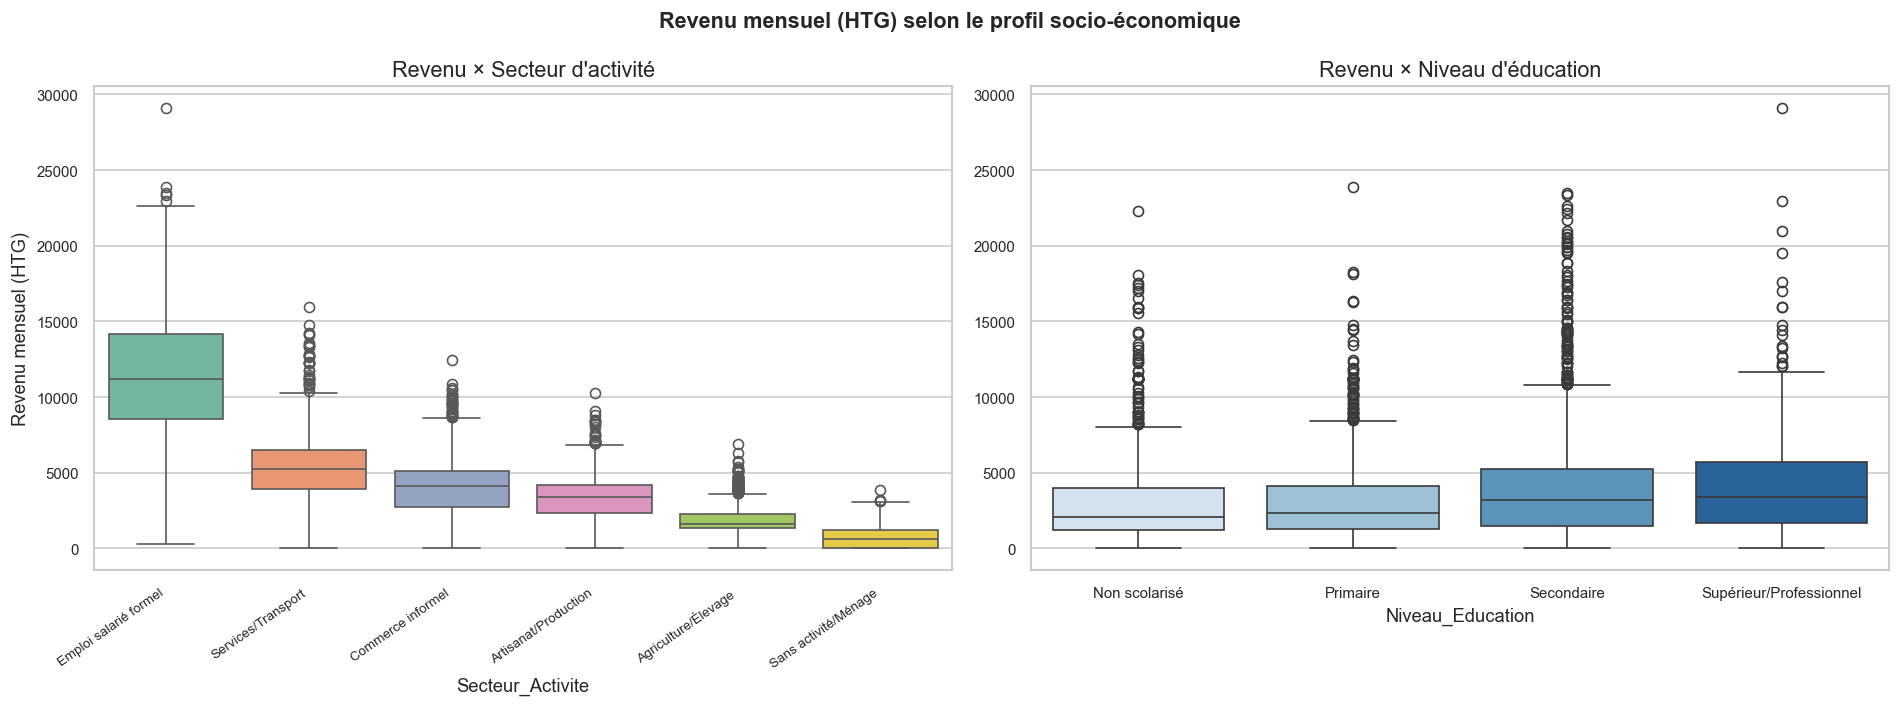

C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Milieu", y="Revenu_Mensuel_HTG", palette="pastel", inner="box", ax=ax)


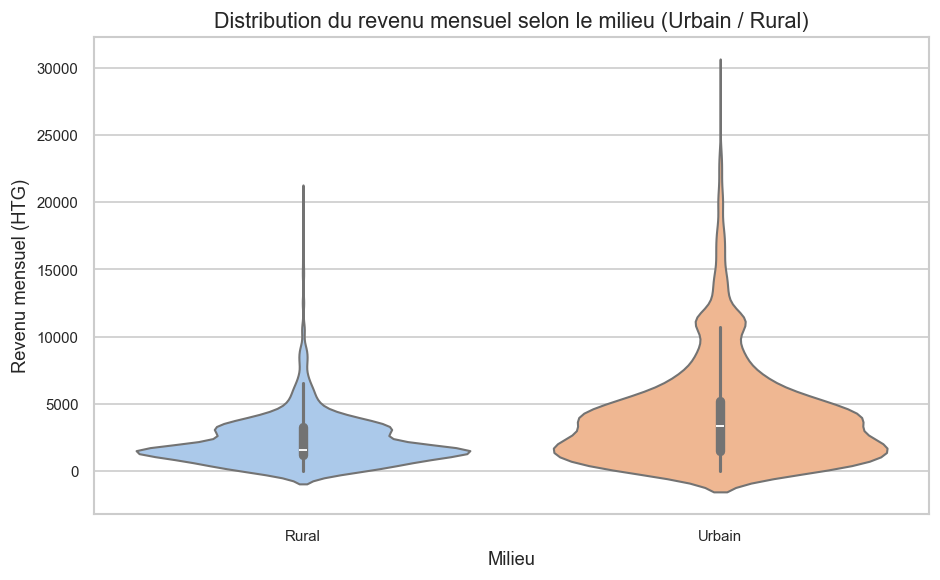


--- 4b. Comportements financiers × profil socio-économique ---

  Taux de 'Oui' par groupe :

  ── Membre_Tontine_Sol ──
    par Milieu : {'Rural': 40.8, 'Urbain': 40.5}
    par Genre : {'Femme': 45.6, 'Homme': 35.3}
    par Secteur_Activite : {'Agriculture/Élevage': 40.1, 'Artisanat/Production': 32.3, 'Commerce informel': 49.0, 'Emploi salarié formel': 32.6, 'Sans activité/Ménage': 39.6, 'Services/Transport': 37.6}
    par Niveau_Education : {'Non scolarisé': 41.7, 'Primaire': 38.2, 'Secondaire': 41.8, 'Supérieur/Professionnel': 38.1}

  ── Mobile_Money ──
    par Milieu : {'Rural': 5.9, 'Urbain': 14.5}
    par Genre : {'Femme': 11.6, 'Homme': 12.4}
    par Secteur_Activite : {'Agriculture/Élevage': 9.3, 'Artisanat/Production': 10.9, 'Commerce informel': 12.3, 'Emploi salarié formel': 18.2, 'Sans activité/Ménage': 12.2, 'Services/Transport': 14.2}
    par Niveau_Education : {'Non scolarisé': 8.8, 'Primaire': 9.3, 'Secondaire': 14.9, 'Supérieur/Professionnel': 14.4}

  ── Epargne_Form

C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=grp, y="pct", ax=ax, palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=grp, y="pct", ax=ax, palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=grp, y="pct", ax=ax, palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py

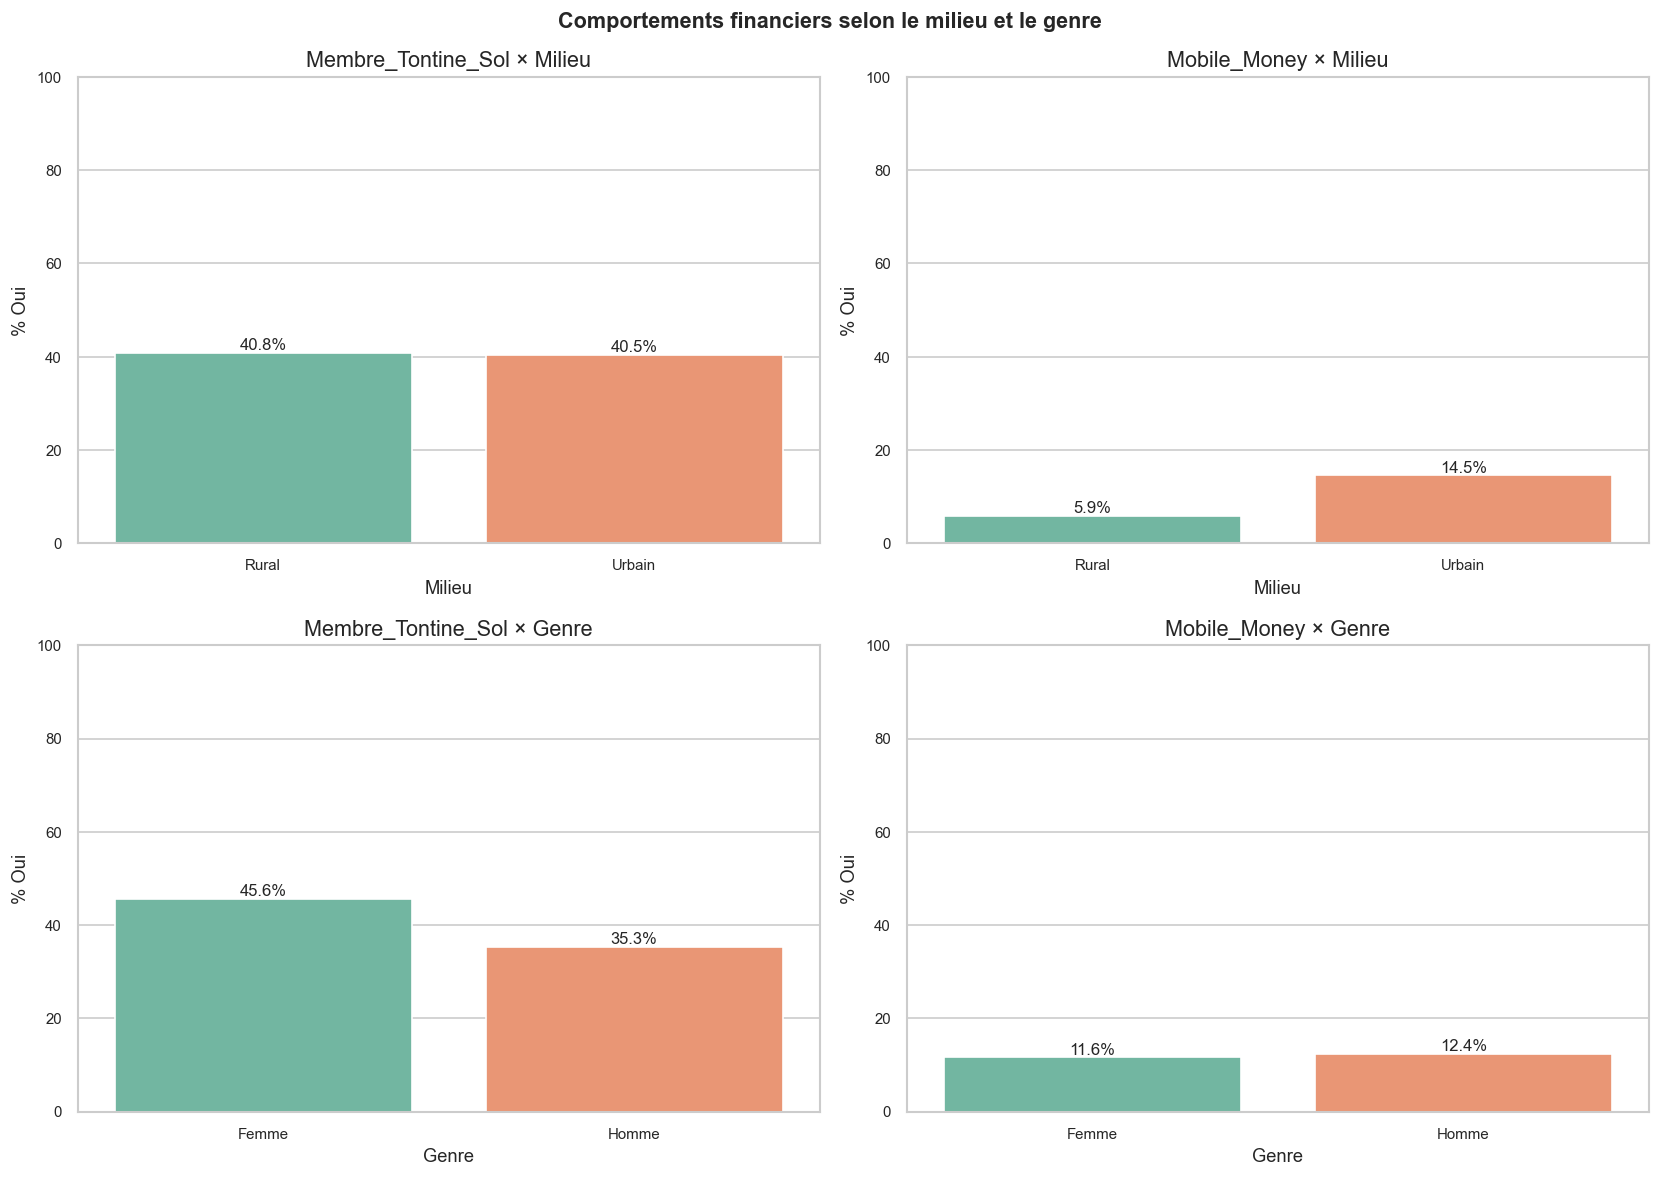

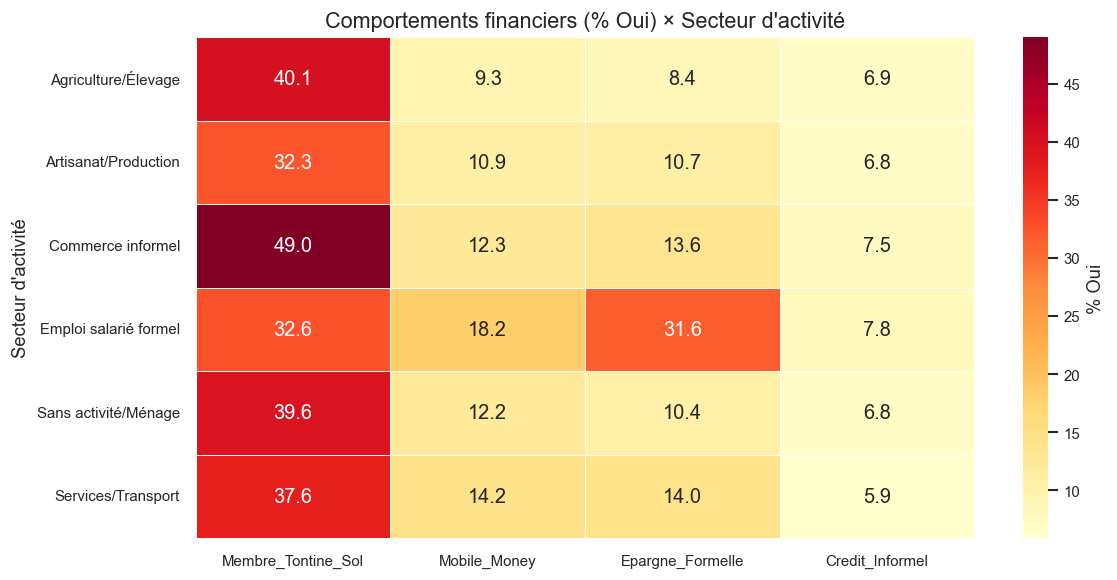


--- 4c. Éligibilité documentaire × profil ---

  Taux de possession par milieu et niveau d'éducation :

  CIN_Carte_Identite
    par Milieu : {'Rural': 54.5, 'Urbain': 69.7}
    par Niveau_Education : {'Non scolarisé': 51.7, 'Primaire': 65.9, 'Secondaire': 71.1, 'Supérieur/Professionnel': 70.4}

  NIF_Matricule_Fiscal
    par Milieu : {'Rural': 25.5, 'Urbain': 29.8}
    par Niveau_Education : {'Non scolarisé': 24.3, 'Primaire': 28.9, 'Secondaire': 28.2, 'Supérieur/Professionnel': 44.4}

  Acte_Naissance
    par Milieu : {'Rural': 92.6, 'Urbain': 94.5}
    par Niveau_Education : {'Non scolarisé': 94.2, 'Primaire': 93.3, 'Secondaire': 94.1, 'Supérieur/Professionnel': 94.2}

  Titre_Propriete
    par Milieu : {'Rural': 12.8, 'Urbain': 14.0}
    par Niveau_Education : {'Non scolarisé': 13.2, 'Primaire': 14.3, 'Secondaire': 14.0, 'Supérieur/Professionnel': 10.9}


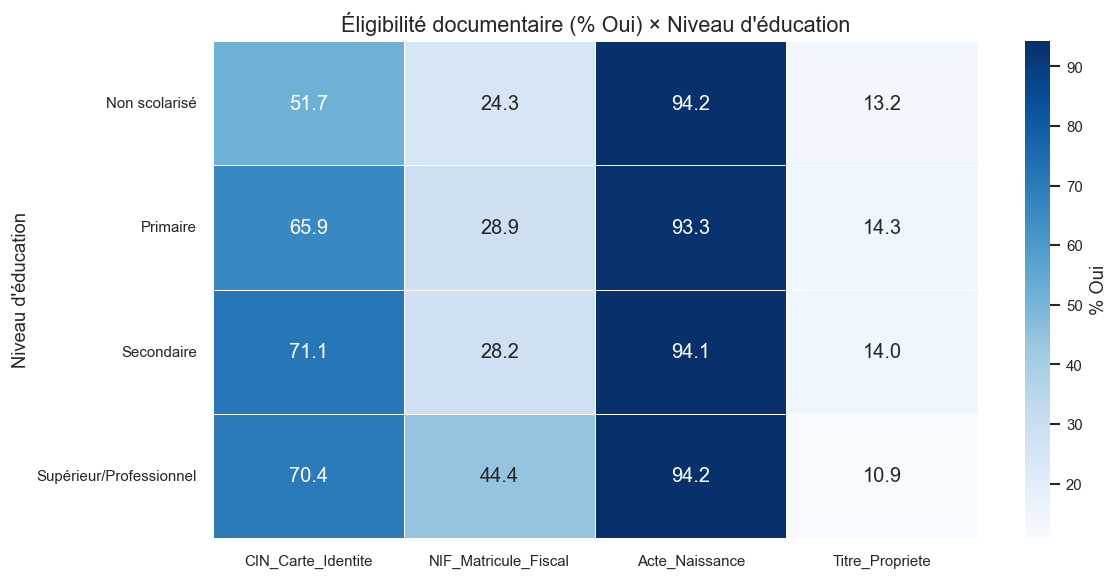


--- 4d. Comportements financiers × Département (cartographie indicative) ---

  Agrégats par département :
                     Membre_Tontine_Sol  Mobile_Money  CIN_Carte_Identite  Manque_Argent_Frequent  Epargne_Formelle  Revenu_median_HTG  n_individus
Departement                                                                                                                                        
Aire Métropolitaine                40.5          19.4                69.3                    61.9              17.9             3373.0         1461
Artibonite                         37.6           9.1                65.2                    64.4              11.1             2431.0          503
Centre                             41.6           5.3                63.0                    66.9               7.8             2161.0          281
Grand-Anse                         36.8           6.5                58.2                    68.2              10.4             1894.0          201
Nipp

C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_d, y="Departement", x="pct", ax=axes[i], palette="Blues_r", orient="h")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_d, y="Departement", x="pct", ax=axes[i], palette="Blues_r", orient="h")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3808\1629637348.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_d, y="Departement", x="pct", ax=ax

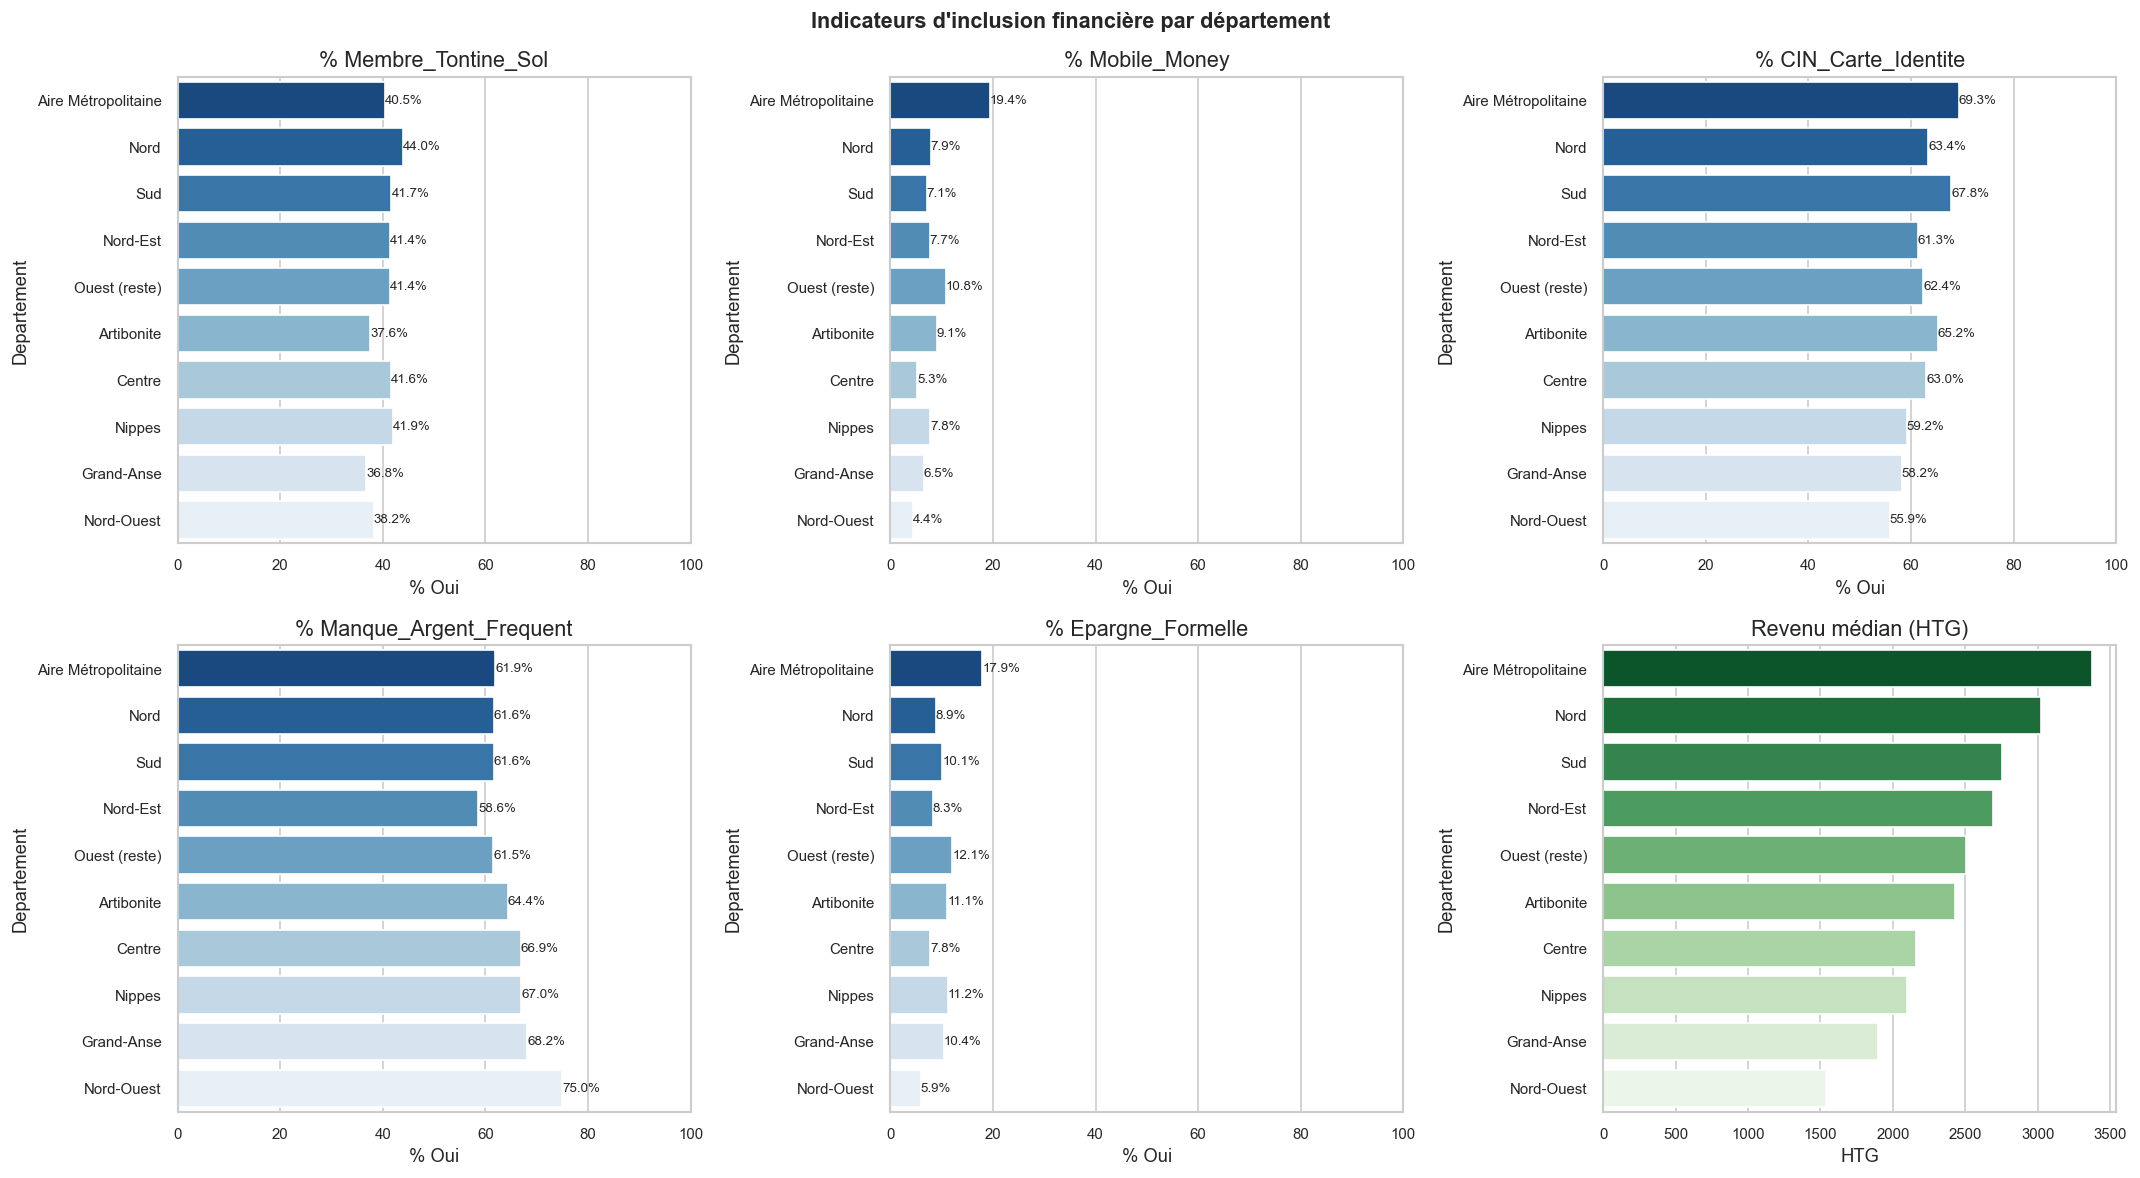

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. ANALYSE BIVARIÉE — CROISEMENTS ORIENTÉS SUJET
# ══════════════════════════════════════════════════════════════════════════════
"""

  A. Qui a des revenus plus élevés ? (capacité économique)
  B. Qui participe aux tontines et au mobile money ? (comportements financiers)
  C. Qui possède les documents nécessaires au crédit ? (éligibilité)
  D. Où se concentrent les profils les plus vulnérables ? (cartographie)
"""

print("\n" + "=" * 65)
print("4. ANALYSE BIVARIÉE")
print("=" * 65)

# ── 4a. Revenu × Profil socio-économique ─────────────────────────────────────
print("\n--- 4a. Revenu mensuel × profil socio-économique ---")
"""
Question : Le revenu varie-t-il selon le secteur d'activité, le milieu,
le niveau d'éducation ? Ces variables discriminent-elles les profils ?
"""

vars_revenu = ["Secteur_Activite", "Milieu", "Niveau_Education", "Genre", "Tranche_Age"]
vars_revenu = [v for v in vars_revenu if v in df.columns]

print("\n  Revenu médian par groupe :")
for var in vars_revenu:
    mediane = df.groupby(var)["Revenu_Mensuel_HTG"].median().sort_values(ascending=False)
    print(f"\n  {var}")
    for k, v in mediane.items():
        print(f"    {str(k):<40} : {v:>8,.0f} HTG")

# Graphique 4 — Revenu × Secteur et Milieu (boxplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Revenu mensuel (HTG) selon le profil socio-économique", fontsize=13, fontweight="bold")

order_secteur = df.groupby("Secteur_Activite")["Revenu_Mensuel_HTG"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Secteur_Activite", y="Revenu_Mensuel_HTG",
            order=order_secteur, ax=axes[0], palette="Set2")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right", fontsize=8)
axes[0].set_title("Revenu × Secteur d'activité")
axes[0].set_ylabel("Revenu mensuel (HTG)")

sns.boxplot(data=df, x="Niveau_Education", y="Revenu_Mensuel_HTG", ax=axes[1],
            order=["Non scolarisé", "Primaire", "Secondaire", "Supérieur/Professionnel"],
            palette="Blues")
axes[1].set_title("Revenu × Niveau d'éducation")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

# Graphique 5 — Revenu × Milieu
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x="Milieu", y="Revenu_Mensuel_HTG", palette="pastel", inner="box", ax=ax)
ax.set_title("Distribution du revenu mensuel selon le milieu (Urbain / Rural)")
ax.set_ylabel("Revenu mensuel (HTG)")
plt.tight_layout()
plt.show()

# ── 4b. Comportements financiers × Profil ────────────────────────────────────
print("\n--- 4b. Comportements financiers × profil socio-économique ---")
"""
Question : Les comportements financiers clés (tontine, mobile money,
épargne formelle, crédit informel) varient-ils selon le milieu, le genre,
le secteur d'activité ? Ce sont les variables discriminantes pour le clustering.
"""

vars_compfin = ["Membre_Tontine_Sol", "Mobile_Money", "Epargne_Formelle", "Credit_Informel"]
vars_compfin = [v for v in vars_compfin if v in df.columns]
axes_group   = ["Milieu", "Genre", "Secteur_Activite", "Niveau_Education"]
axes_group   = [v for v in axes_group if v in df.columns]

print("\n  Taux de 'Oui' par groupe :")
for comp in vars_compfin:
    print(f"\n  ── {comp} ──")
    for grp in axes_group:
        taux = df.groupby(grp)[comp].apply(lambda x: (x == "Oui").mean() * 100).round(1)
        print(f"    par {grp} : {taux.to_dict()}")

# Graphique 6 — Tontine et Mobile Money × Milieu et Genre (barres groupées)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Comportements financiers selon le milieu et le genre", fontsize=13, fontweight="bold")

for idx, (comp, grp) in enumerate([
    ("Membre_Tontine_Sol", "Milieu"),
    ("Mobile_Money",       "Milieu"),
    ("Membre_Tontine_Sol", "Genre"),
    ("Mobile_Money",       "Genre"),
]):
    if comp not in df.columns or grp not in df.columns:
        continue
    ax = axes[idx // 2][idx % 2]
    data = df.groupby(grp)[comp].apply(lambda x: (x == "Oui").mean() * 100).reset_index()
    data.columns = [grp, "pct"]
    sns.barplot(data=data, x=grp, y="pct", ax=ax, palette="Set2")
    ax.set_title(f"{comp} × {grp}")
    ax.set_ylabel("% Oui")
    ax.set_ylim(0, 100)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

# Graphique 7 — Comportements financiers × Secteur d'activité (heatmap des taux)
data_heatmap = pd.DataFrame()
for comp in vars_compfin:
    if comp in df.columns:
        taux = df.groupby("Secteur_Activite")[comp].apply(lambda x: (x == "Oui").mean() * 100).round(1)
        data_heatmap[comp] = taux

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(data_heatmap, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "% Oui"})
ax.set_title("Comportements financiers (% Oui) × Secteur d'activité")
ax.set_ylabel("Secteur d'activité")
plt.tight_layout()
plt.show()

# ── 4c. Éligibilité documentaire × Profil ─────────────────────────────────────
print("\n--- 4c. Éligibilité documentaire × profil ---")
"""
Question : La possession de documents requis pour un crédit (CIN, NIF)
varie-t-elle selon le milieu, l'éducation, le secteur ?
Ce sont des variables proxy d'accessibilité au microcrédit.
"""

vars_doc = ["CIN_Carte_Identite", "NIF_Matricule_Fiscal", "Acte_Naissance", "Titre_Propriete"]
vars_doc = [v for v in vars_doc if v in df.columns]

print("\n  Taux de possession par milieu et niveau d'éducation :")
for doc in vars_doc:
    print(f"\n  {doc}")
    for grp in ["Milieu", "Niveau_Education"]:
        if grp in df.columns:
            taux = df.groupby(grp)[doc].apply(lambda x: (x == "Oui").mean() * 100).round(1)
            print(f"    par {grp} : {taux.to_dict()}")

# Graphique 8 — Documentation × Milieu et Éducation
data_doc = pd.DataFrame()
for doc in vars_doc:
    if doc in df.columns:
        taux = df.groupby("Niveau_Education")[doc].apply(lambda x: (x == "Oui").mean() * 100).round(1)
        data_doc[doc] = taux

ordre_educ = ["Non scolarisé", "Primaire", "Secondaire", "Supérieur/Professionnel"]
data_doc = data_doc.reindex([e for e in ordre_educ if e in data_doc.index])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(data_doc, annot=True, fmt=".1f", cmap="Blues", ax=ax,
            linewidths=0.5, cbar_kws={"label": "% Oui"})
ax.set_title("Éligibilité documentaire (% Oui) × Niveau d'éducation")
ax.set_ylabel("Niveau d'éducation")
plt.tight_layout()
plt.show()

# ── 4d. Comportements financiers × Département ────────────────────────────────
print("\n--- 4d. Comportements financiers × Département (cartographie indicative) ---")
"""
Question : Où se concentrent les ménages les plus exclus financièrement ?
Cette analyse prépare la cartographie thématique du dashboard.
"""

vars_carte = ["Membre_Tontine_Sol", "Mobile_Money", "CIN_Carte_Identite",
              "Manque_Argent_Frequent", "Epargne_Formelle"]
vars_carte = [v for v in vars_carte if v in df.columns]

agg_dept = pd.DataFrame()
for var in vars_carte:
    agg_dept[var] = df.groupby("Departement")[var].apply(lambda x: (x == "Oui").mean() * 100).round(1)
agg_dept["Revenu_median_HTG"] = df.groupby("Departement")["Revenu_Mensuel_HTG"].median().round(0)
agg_dept["n_individus"] = df.groupby("Departement").size()

print("\n  Agrégats par département :")
print(agg_dept.to_string())

# Graphique 9 — Indicateurs par département (barres horizontales multiples)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Indicateurs d'inclusion financière par département", fontsize=13, fontweight="bold")
axes = axes.flatten()

dept_order = df.groupby("Departement")["Revenu_Mensuel_HTG"].median().sort_values(ascending=False).index

for i, var in enumerate(vars_carte):
    data_d = agg_dept[var].reindex(dept_order).reset_index()
    data_d.columns = ["Departement", "pct"]
    sns.barplot(data=data_d, y="Departement", x="pct", ax=axes[i], palette="Blues_r", orient="h")
    axes[i].set_title(f"% {var}")
    axes[i].set_xlabel("% Oui")
    axes[i].set_xlim(0, 100)
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_width():.1f}%",
                         (p.get_width(), p.get_y() + p.get_height() / 2),
                         ha="left", va="center", fontsize=8)

# Revenu médian par département
data_r = agg_dept["Revenu_median_HTG"].reindex(dept_order).reset_index()
data_r.columns = ["Departement", "rev"]
sns.barplot(data=data_r, y="Departement", x="rev", ax=axes[5], palette="Greens_r", orient="h")
axes[5].set_title("Revenu médian (HTG)")
axes[5].set_xlabel("HTG")
plt.tight_layout()
plt.show()



5. TESTS STATISTIQUES

--- 5a. Test de normalité de Shapiro-Wilk ---

  Age
    Shapiro-Wilk : W=0.9377, p=4.1923e-38  →  NON NORMALE (rejeter H0)

  Revenu_Mensuel_HTG
    Shapiro-Wilk : W=0.8083, p=2.0803e-56  →  NON NORMALE (rejeter H0)


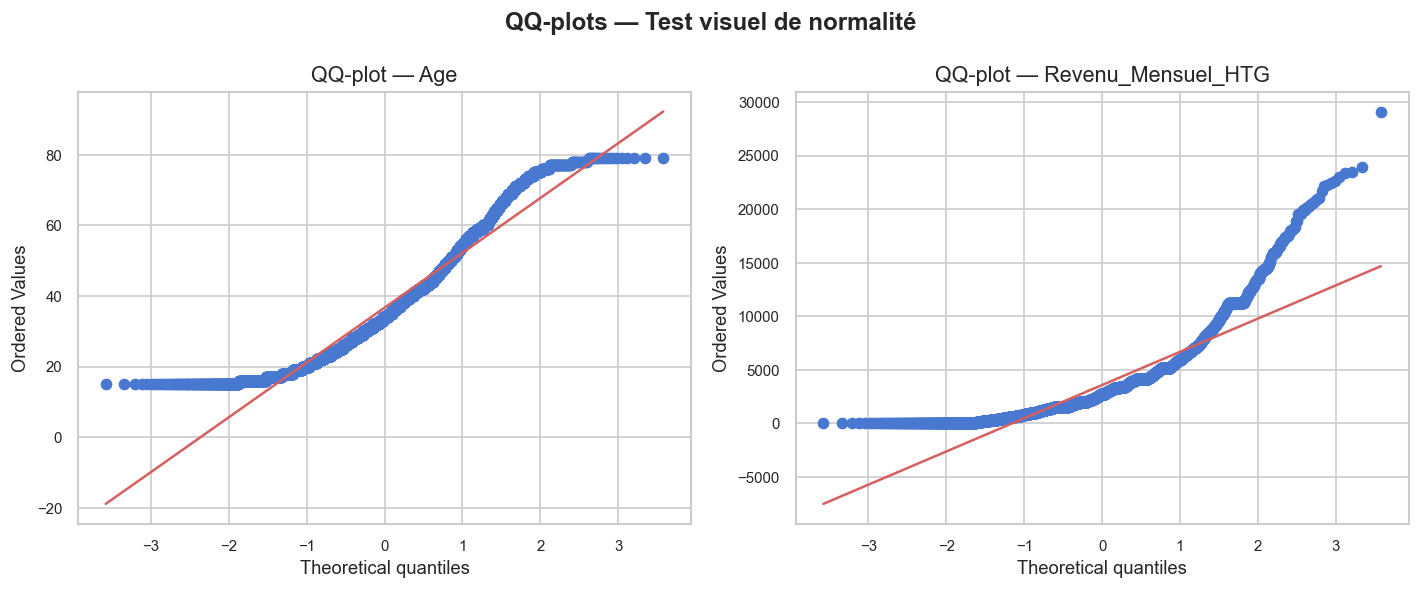


--- 5b. Tests de comparaison de groupes ---

  Mann-Whitney — Revenu × Milieu
    Urbain   : médiane=3380 HTG (n=2840)
    Rural    : médiane=1540 HTG (n=1176)
    U=2200678, p=9.2119e-57
    Conclusion : Différence significative (rejeter H0)

  Mann-Whitney — Revenu × Genre
    Homme    : médiane=2737 HTG (n=1969)
    Femme    : médiane=2756 HTG (n=2047)
    U=2027470, p=7.3977e-01
    Conclusion : Pas de différence significative

  Kruskal-Wallis — Revenu × Secteur d'activité
    H=2179.475, p=0.0000e+00
    Conclusion : Différence significative entre secteurs (rejeter H0)

  Kruskal-Wallis — Revenu × Niveau d'éducation
    H=69.396, p=5.7494e-15
    Conclusion : Différence significative (rejeter H0)

  Kruskal-Wallis — Revenu × Niveau d'inclusion financière
    H=148.722, p=4.9719e-32
    Conclusion : Différence significative (rejeter H0)

--- 5c. Tests d'association (Khi-deux + V de Cramér) ---

  Variable 1                     Variable 2                           Chi2      p-valu

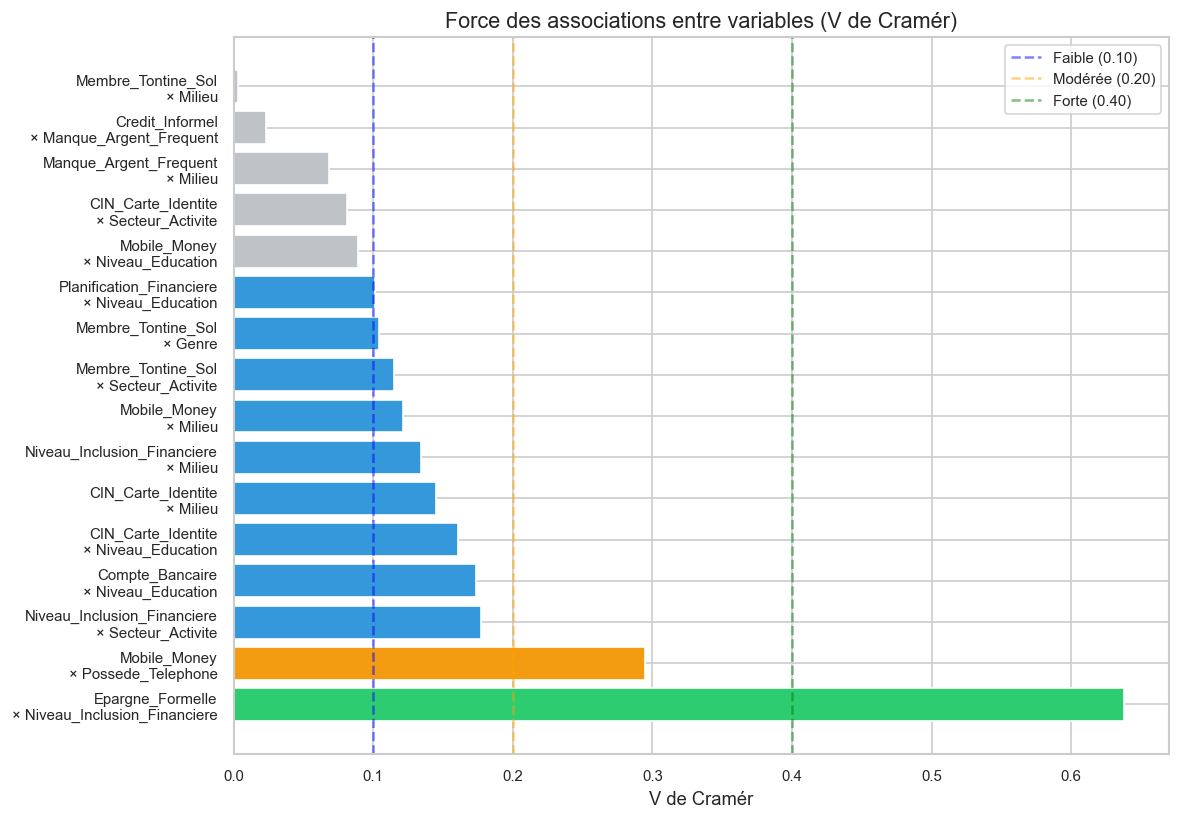


--- 5d. Corrélations de Spearman (variables ordinales/numériques) ---

  Matrice de corrélation de Spearman :
                          Age  Revenu_Mensuel_HTG  Educ_code  Planif_code  Inclusion_code  CIN_Carte_Identite  Membre_Tontine_Sol  Mobile_Money  Epargne_Formelle  Manque_Argent_Frequent  Credit_Informel
Age                     1.000               0.000     -0.001       -0.005          -0.012              -0.009              -0.004        -0.009             0.001                   0.018            0.004
Revenu_Mensuel_HTG      0.000               1.000      0.130        0.047           0.190               0.064               0.010         0.056             0.115                  -0.245           -0.011
Educ_code              -0.001               0.130      1.000        0.086           0.217               0.145               0.002         0.083             0.095                  -0.028           -0.005
Planif_code            -0.005               0.047      0.086        1.000    

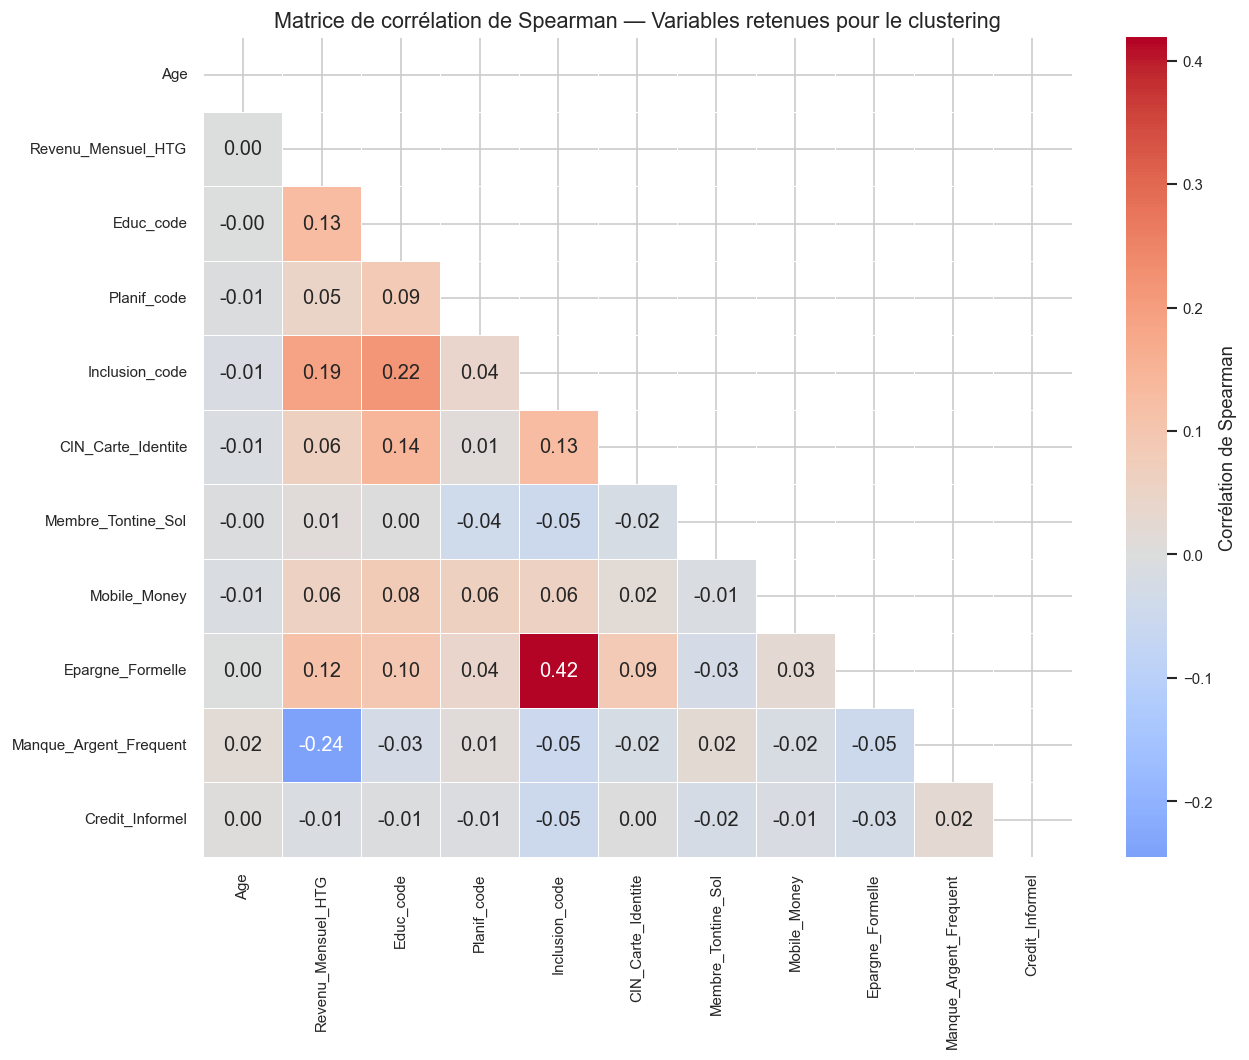

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. TESTS STATISTIQUES
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("5. TESTS STATISTIQUES")
print("=" * 65)

# ── 5a. Test de normalité (Shapiro-Wilk) ──────────────────────────────────────
print("\n--- 5a. Test de normalité de Shapiro-Wilk ---")
"""
Hypothèses :
  H0 : La variable suit une distribution normale
  H1 : La variable ne suit pas une distribution normale
Seuil : α = 0.05
"""

# Shapiro-Wilk recommandé pour n < 5000, sinon on commente les QQ-plots
n_test = min(5000, len(df))
sample_df = df.sample(n=n_test, random_state=42)

for var in VARS_NUM:
    stat, p = shapiro(sample_df[var])
    conclusion = "NON NORMALE (rejeter H0)" if p < 0.05 else "Normale (ne pas rejeter H0)"
    print(f"\n  {var}")
    print(f"    Shapiro-Wilk : W={stat:.4f}, p={p:.4e}  →  {conclusion}")

# Graphique 10 — QQ-plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("QQ-plots — Test visuel de normalité", fontweight="bold")
for i, var in enumerate(VARS_NUM):
    stats.probplot(df[var], dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ-plot — {var}")
plt.tight_layout()
plt.show()

# ── 5b. Comparaison de groupes (Mann-Whitney / Kruskal-Wallis) ─────────────────
print("\n--- 5b. Tests de comparaison de groupes ---")
"""
Étant donné la non-normalité des variables numériques (attendue d'après
les histogrammes et le Shapiro), on utilise les tests non paramétriques :
  - Mann-Whitney U : pour comparer 2 groupes indépendants
  - Kruskal-Wallis  : pour comparer 3 groupes ou plus
"""

# Test Mann-Whitney : Revenu selon Milieu (2 groupes)
g_urbain = df[df["Milieu"] == "Urbain"]["Revenu_Mensuel_HTG"]
g_rural  = df[df["Milieu"] == "Rural"]["Revenu_Mensuel_HTG"]
stat_mw, p_mw = mannwhitneyu(g_urbain, g_rural, alternative="two-sided")
print(f"\n  Mann-Whitney — Revenu × Milieu")
print(f"    Urbain   : médiane={g_urbain.median():.0f} HTG (n={len(g_urbain)})")
print(f"    Rural    : médiane={g_rural.median():.0f} HTG (n={len(g_rural)})")
print(f"    U={stat_mw:.0f}, p={p_mw:.4e}")
print(f"    Conclusion : {'Différence significative (rejeter H0)' if p_mw < 0.05 else 'Pas de différence significative'}")

# Test Mann-Whitney : Revenu selon Genre
g_h = df[df["Genre"] == "Homme"]["Revenu_Mensuel_HTG"]
g_f = df[df["Genre"] == "Femme"]["Revenu_Mensuel_HTG"]
stat_g, p_g = mannwhitneyu(g_h, g_f, alternative="two-sided")
print(f"\n  Mann-Whitney — Revenu × Genre")
print(f"    Homme    : médiane={g_h.median():.0f} HTG (n={len(g_h)})")
print(f"    Femme    : médiane={g_f.median():.0f} HTG (n={len(g_f)})")
print(f"    U={stat_g:.0f}, p={p_g:.4e}")
print(f"    Conclusion : {'Différence significative' if p_g < 0.05 else 'Pas de différence significative'}")

# Test Kruskal-Wallis : Revenu selon Secteur d'activité (> 2 groupes)
groupes_secteur = [g["Revenu_Mensuel_HTG"].values
                   for _, g in df.groupby("Secteur_Activite")]
stat_kw, p_kw = kruskal(*groupes_secteur)
print(f"\n  Kruskal-Wallis — Revenu × Secteur d'activité")
print(f"    H={stat_kw:.3f}, p={p_kw:.4e}")
print(f"    Conclusion : {'Différence significative entre secteurs (rejeter H0)' if p_kw < 0.05 else 'Pas de différence significative'}")

# Test Kruskal-Wallis : Revenu selon Niveau d'éducation
groupes_educ = [g["Revenu_Mensuel_HTG"].values
                for _, g in df.groupby("Niveau_Education")]
stat_ke, p_ke = kruskal(*groupes_educ)
print(f"\n  Kruskal-Wallis — Revenu × Niveau d'éducation")
print(f"    H={stat_ke:.3f}, p={p_ke:.4e}")
print(f"    Conclusion : {'Différence significative (rejeter H0)' if p_ke < 0.05 else 'Pas de différence significative'}")

# Test Kruskal-Wallis : Revenu selon Niveau d'inclusion financière
groupes_incl = [g["Revenu_Mensuel_HTG"].values
                for _, g in df.groupby("Niveau_Inclusion_Financiere")]
stat_ki, p_ki = kruskal(*groupes_incl)
print(f"\n  Kruskal-Wallis — Revenu × Niveau d'inclusion financière")
print(f"    H={stat_ki:.3f}, p={p_ki:.4e}")
print(f"    Conclusion : {'Différence significative (rejeter H0)' if p_ki < 0.05 else 'Pas de différence significative'}")

# ── 5c. Tests d'association — Khi-deux + V de Cramér ──────────────────────────
print("\n--- 5c. Tests d'association (Khi-deux + V de Cramér) ---")
"""
Pour tester l'association entre deux variables catégorielles/binaires.
H0 : les deux variables sont indépendantes
H1 : il existe une association entre les deux variables

V de Cramér mesure la force de l'association :
  < 0.10  : association négligeable
  0.10–0.20 : faible
  0.20–0.40 : modérée
  > 0.40  : forte
"""

def v_cramer(var1, var2, dataframe):
    """Calcule le V de Cramér entre deux variables catégorielles."""
    contingency = pd.crosstab(dataframe[var1], dataframe[var2])
    chi2, p, dof, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    return chi2, p, dof, v

# Paires de croisements pertinents pour le sujet
paires = [
    ("Membre_Tontine_Sol",   "Genre"),
    ("Membre_Tontine_Sol",   "Milieu"),
    ("Membre_Tontine_Sol",   "Secteur_Activite"),
    ("Mobile_Money",         "Milieu"),
    ("Mobile_Money",         "Possede_Telephone"),
    ("Mobile_Money",         "Niveau_Education"),
    ("CIN_Carte_Identite",   "Milieu"),
    ("CIN_Carte_Identite",   "Niveau_Education"),
    ("CIN_Carte_Identite",   "Secteur_Activite"),
    ("Epargne_Formelle",     "Niveau_Inclusion_Financiere"),
    ("Credit_Informel",      "Manque_Argent_Frequent"),
    ("Planification_Financiere", "Niveau_Education"),
    ("Manque_Argent_Frequent",   "Milieu"),
    ("Compte_Bancaire",      "Niveau_Education"),
    ("Niveau_Inclusion_Financiere", "Milieu"),
    ("Niveau_Inclusion_Financiere", "Secteur_Activite"),
]

resultats_khi2 = []
print(f"\n  {'Variable 1':<30} {'Variable 2':<30} {'Chi2':>10} {'p-value':>12} {'V Cramér':>10} {'Interprétation'}")
print("  " + "-" * 105)

for v1, v2 in paires:
    if v1 not in df.columns or v2 not in df.columns:
        continue
    try:
        chi2_val, p_val, dof, v = v_cramer(v1, v2, df)
        if v < 0.10:    interp = "Négligeable"
        elif v < 0.20:  interp = "Faible"
        elif v < 0.40:  interp = "Modérée"
        else:           interp = "Forte"
        sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
        print(f"  {v1:<30} {v2:<30} {chi2_val:>10.2f} {p_val:>12.4e} {v:>10.3f}  {interp} {sig}")
        resultats_khi2.append({"Var1": v1, "Var2": v2, "Chi2": round(chi2_val, 2),
                                "p_value": round(p_val, 6), "V_Cramer": round(v, 3),
                                "Interpretation": interp, "Significativite": sig})
    except Exception as e:
        print(f"  {v1} × {v2} : erreur ({e})")

df_khi2 = pd.DataFrame(resultats_khi2).sort_values("V_Cramer", ascending=False)

# Graphique 11 — V de Cramér (classement des associations)
fig, ax = plt.subplots(figsize=(10, 7))
labels = [f"{r['Var1']}\n× {r['Var2']}" for _, r in df_khi2.iterrows()]
colors = ["#2ecc71" if v >= 0.40 else "#f39c12" if v >= 0.20 else "#3498db" if v >= 0.10 else "#bdc3c7"
          for v in df_khi2["V_Cramer"]]
bars = ax.barh(labels, df_khi2["V_Cramer"].values, color=colors)
ax.axvline(0.10, color="blue",   linestyle="--", alpha=0.5, label="Faible (0.10)")
ax.axvline(0.20, color="orange", linestyle="--", alpha=0.5, label="Modérée (0.20)")
ax.axvline(0.40, color="green",  linestyle="--", alpha=0.5, label="Forte (0.40)")
ax.set_xlabel("V de Cramér")
ax.set_title("Force des associations entre variables (V de Cramér)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── 5d. Corrélation de Spearman entre variables ordinales/numériques ──────────
print("\n--- 5d. Corrélations de Spearman (variables ordinales/numériques) ---")
"""
Spearman est adapté aux variables non normales et aux variables ordinales encodées.
"""

# Encodage rapide pour les corrélations (sans modifier le df principal)
df_corr = df[["Age", "Revenu_Mensuel_HTG"]].copy()

# Encodages ordinaux pour corrélation
df_corr["Educ_code"] = df["Niveau_Education"].map(
    {"Non scolarisé": 0, "Primaire": 1, "Secondaire": 2, "Supérieur/Professionnel": 3})
df_corr["Planif_code"] = df["Planification_Financiere"].map(
    {"Jamais": 0, "Pas souvent": 1, "Ne sait pas": 1, "Souvent": 2, "Toujours": 3})
df_corr["Inclusion_code"] = df["Niveau_Inclusion_Financiere"].map(
    {"Exclus financièrement": 0, "Informel seulement": 1,
     "Autre formel (non-bancaire)": 2, "Bancarisé": 3})

# Binaires numériques
for var in ["CIN_Carte_Identite", "Membre_Tontine_Sol", "Mobile_Money",
            "Epargne_Formelle", "Manque_Argent_Frequent", "Credit_Informel"]:
    if var in df.columns:
        df_corr[var] = (df[var] == "Oui").astype(int)

corr_matrix = df_corr.corr(method="spearman").round(3)
print("\n  Matrice de corrélation de Spearman :")
print(corr_matrix.to_string())

# Graphique 12 — Heatmap de Spearman
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, linewidths=0.5,
            cbar_kws={"label": "Corrélation de Spearman"})
ax.set_title("Matrice de corrélation de Spearman — Variables retenues pour le clustering")
plt.tight_layout()
plt.show()


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. SYNTHÈSE DES INDICATEURS CLÉS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("6. SYNTHÈSE DES INDICATEURS CLÉS — POPULATION CIBLE")
print("=" * 65)

indicateurs = {
    "Taille population cible"           : len(df),
    "Âge moyen (ans)"                   : round(df["Age"].mean(), 1),
    "Âge médian (ans)"                  : int(df["Age"].median()),
    "Revenu moyen (HTG)"                : round(df["Revenu_Mensuel_HTG"].mean(), 0),
    "Revenu médian (HTG)"               : int(df["Revenu_Mensuel_HTG"].median()),
    "% Femme"                           : round((df["Genre"] == "Femme").mean()*100, 1),
    "% Milieu urbain"                   : round((df["Milieu"] == "Urbain").mean()*100, 1),
    "% Non scolarisé ou primaire"       : round(df["Niveau_Education"].isin(["Non scolarisé", "Primaire"]).mean()*100, 1),
    "% Exclus financièrement"           : round((df["Niveau_Inclusion_Financiere"] == "Exclus financièrement").mean()*100, 1),
    "% Possède CIN"                     : round((df["CIN_Carte_Identite"] == "Oui").mean()*100, 1),
    "% Membre tontine (sòl)"            : round((df["Membre_Tontine_Sol"] == "Oui").mean()*100, 1),
    "% Usage mobile money"              : round((df["Mobile_Money"] == "Oui").mean()*100, 1),
    "% Épargne formelle"                : round((df["Epargne_Formelle"] == "Oui").mean()*100, 1),
    "% Crédit informel"                 : round((df["Credit_Informel"] == "Oui").mean()*100, 1),
    "% Manque d'argent fréquent"        : round((df["Manque_Argent_Frequent"] == "Oui").mean()*100, 1),
    "% Planification financière (jamais)": round((df["Planification_Financiere"] == "Jamais").mean()*100, 1),
}

print(f"\n  {'Indicateur':<45} {'Valeur':>10}")
print("  " + "-" * 57)
for k, v in indicateurs.items():
    print(f"  {k:<45} {str(v):>10}")




6. SYNTHÈSE DES INDICATEURS CLÉS — POPULATION CIBLE

  Indicateur                                        Valeur
  ---------------------------------------------------------
  Taille population cible                             4016
  Âge moyen (ans)                                     36.7
  Âge médian (ans)                                      34
  Revenu moyen (HTG)                                3589.0
  Revenu médian (HTG)                                 2756
  % Femme                                             51.0
  % Milieu urbain                                     70.7
  % Non scolarisé ou primaire                         49.4
  % Exclus financièrement                             48.2
  % Possède CIN                                       65.3
  % Membre tontine (sòl)                              40.6
  % Usage mobile money                                12.0
  % Épargne formelle                                  12.8
  % Crédit informel                                    7.0
 